<a href="https://colab.research.google.com/github/Nurdaylight/An-Econ-771/blob/main/PS3/Ps3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [146]:

from scipy.stats import norm
import numpy as np
import torch
import matplotlib.pyplot as plt
import math

In [147]:
# This is for the timing of the code run time, please do not modify
import time
start_time = time.time()

# I

# Part **a**

In [148]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#Params

M = 5000
n = 20
beta_true = torch.tensor([1.0, 2.0, 3.0], device=device)  # (β1, β2, β3)

#>--------------------------------------------------------

# Generate tensor of all data with dimensions M*N*K
X = torch.randn(M, n, 3, device=device)

#Notice in last dimension first vector is residuals times1
#  and constant is added after

Y= X@beta_true +1.0

#store errors, replace constant into regression data
errors = X[:, :, 0].clone()
X[:, :, 0] = 1.0

# Compute estimates
XtX = X.transpose(1, 2) @ X      # shape: (M, 3, 3)
XtX_inv = torch.linalg.inv(XtX)  # shape: (M, 3, 3)

beta_hat= XtX_inv @ X.transpose(1, 2)@Y.view(M, n, 1)

**Answer**: all estimates are stored in  ```beta_hat```  which is too large to print [ (M*3) matrix ]



> ---------------------------------------------------------------




#  Part **b**

In [149]:
#Use the fact that sigma is known and = 1

# ---- extract diagonal using torch ONLY ----
XtX_inv_diag = torch.diagonal(XtX_inv, dim1=1, dim2=2)   # (M, 3)

# ---- standard errors ----
se = torch.sqrt(1 * XtX_inv_diag)
diff=(beta_hat - beta_true.view(1,-1,1)).view(M,3)                     # (M, 3)
z= diff/se   # (M, 3)



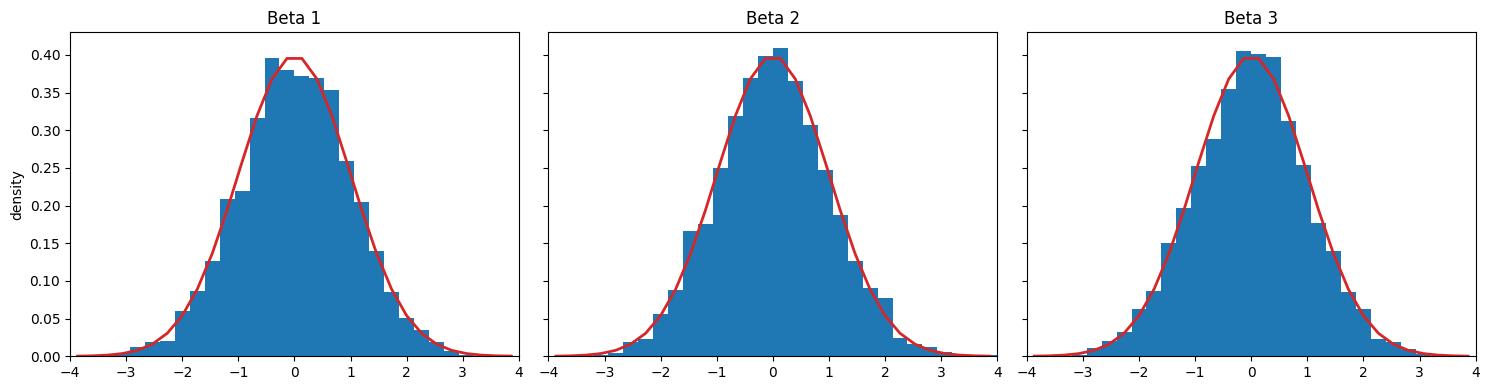

In [150]:

z_cpu = z.cpu()
edges = torch.linspace(-4, 4, 31)   # 40 bins => 41 edges
widths = (edges[1:] - edges[:-1])

centers = 0.5 * (edges[1:] + edges[:-1])

# standard normal pdf at centers (no linspace needed beyond edges)
phi = (1 / math.sqrt(2 * math.pi)) * torch.exp(-0.5 * centers**2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for k, ax in enumerate(axes):
    counts = torch.histc(z_cpu[:, k], bins=30, min=-4.0, max=4.0)  # counts per bin
    density = counts / (counts.sum() * widths)                     # convert to density

    ax.bar(centers, density, width=widths, align="center")
    ax.plot(centers, phi,color="tab:red", linewidth=2)
    ax.set_title(f"Beta {k+1}")
    ax.set_xlim(-4, 4)

axes[0].set_ylabel("density")
plt.tight_layout()
plt.show()

# Part **c**


In [151]:
#F
error_hat= Y.view(M,n,1) - (X@beta_hat)
var=error_hat.transpose(1,2)@error_hat /(n-3)
se_hat=torch.sqrt(var.squeeze(-1)   * XtX_inv_diag)
t=diff /se_hat

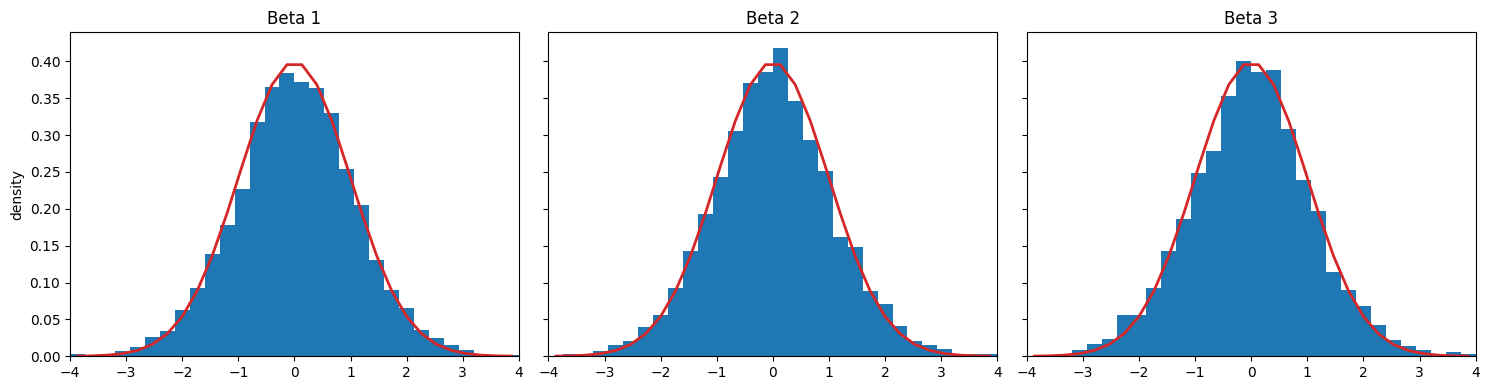

In [152]:
t_cpu = t.cpu()



fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for k, ax in enumerate(axes):
    counts = torch.histc(t_cpu[:, k], bins=30, min=-4.0, max=4.0)  # counts per bin
    density = counts / (counts.sum() * widths)                     # convert to density

    ax.bar(centers, density, width=widths, align="center")
    ax.plot(centers, phi,color="tab:red", linewidth=2)
    ax.set_title(f"Beta {k+1}")
    ax.set_xlim(-4, 4)

axes[0].set_ylabel("density")
plt.tight_layout()
plt.show()

**Answer:** this estimator is distributed according to T distribution with n-k (17) degrees of freedom.

> ---------------------------------------------------------------

# Part **d**

In [153]:
crit=  2.110 #Analytical threshold (GOOGLED)
false_pos = (torch.sum((t > crit) | (t < -crit), dim=0))/M
print(f"rate of false positives is {false_pos.tolist()}")

rate of false positives is [0.05040000006556511, 0.05339999869465828, 0.05719999969005585]


# Part **e**

how often we reject `beta = 0`?

In [154]:
#F

t_0=beta_hat.squeeze(-1) /se_hat
false_pos_0 = (torch.sum((t_0 > crit) | (t_0 < -crit), dim=0))/M
print(f"Rate of two sided null rejection is {false_pos_0.tolist()}")

Rate of two sided null rejection is [0.9761999845504761, 1.0, 1.0]


# Part **f**

# Answer:


Part (d): The calculated 'false_pos' represents the rate of Type I errors (incorrectly rejecting the true null hypothesis)

when using the t-statistic (with estimated variance) to test if `beta_true` is different from the estimated beta_hat.

the rate was relativeley close to the chosen significance level (e.g., 0.05). Which rmpirically supports the fact that it is indeed t-distributed variable.


Part (e): The 'false_pos_0' represents the rate at which the null hypothesis (`beta = 0`) is rejected.

Since the true betas (`beta_true`) are `[1.0, 2.0, 3.0]` and are not zero, we expect a high rejection rate for `beta = 0`.

This indicates the power of the test to correctly reject a false null hypothesis. We can see this value increased in absolute size of beta. If true beta is different from zero but very close it, is harder to differenciate it compared to the case with large absolute betas.

# **2** Heteroskedasticity

In [155]:
# Generate tensor of all data with dimensions M*N*K


#store errors, replace constant into regression data
errors.shape

torch.Size([5000, 20])

In [156]:
X2 = torch.randn(M, n, 3, device=device)

X2[:, :, 0] = X2[:, :, 0] * (X2[:, :, 1] + X2[:, :, 2])

Y2= X2@beta_true +1.0

X2[:, :, 0] = 1.0

Compute OLS estimator

In [157]:
# Compute estimates
XtX2 = X2.transpose(1, 2) @ X2      # shape: (M, 3, 3)
XtX2_inv = torch.linalg.inv(XtX2)  # shape: (M, 3, 3)

beta_hat2= XtX2_inv @ X2.transpose(1, 2)@Y2.view(M, n, 1)

All estimates for 5000 (M) experiments are stored in `beta_hat2`

 with dimensions MxKx1 (`[5000, 3, 1]`)

In [158]:
#F
diff2=(beta_hat2 - beta_true.view(1,-1,1)).view(M,3)
XtX2_inv_diag = torch.diagonal(XtX2_inv, dim1=1, dim2=2)   # (M, 3)

error_hat2= Y2.view(M,n,1) - (X2@beta_hat2)
var2=error_hat2.transpose(1,2)@error_hat2 /(n-3)
se_hat2=torch.sqrt(var2.squeeze(-1)   * XtX2_inv_diag)

t2= diff2/se_hat2

In [159]:
false_pos2 = (torch.sum((t2 > crit) | (t2 < -crit), dim=0))/M
print(f"rate of false positives is {false_pos2.tolist()}")

rate of false positives is [0.041600000113248825, 0.141199991106987, 0.14980000257492065]


In [160]:
# This is for the timing of the code run time, please do not modify
end_time = time.time()

In [161]:
end_time-start_time

1.3514738082885742